In [1]:
import pandas as pd

df = pd.read_csv('/content/Thiranex_Task4_Raw_Dataset.csv')

df.head()

,Customer_ID,Customer_Name,City,Age,Gender,Income,Status,Transaction_Date
0,101,Rahul,Pune,25.0,Male,45000.0,Completed,2026-01-05
1,102,Sneha,Mumbai,28.0,Female,52000.0,completed,2026-01-08
2,103,Amit,pune,31.0,M,48000.0,Pending,2026-01-12
3,104,Priya,Nashik,NaN,Female,61000.0,Completed,2026-01-15
4,105,Rohan,Mumbai,24.0,Male,39000.0,pending,2026-01-18


In [2]:
# check missing values
df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
City,0
Age,2
Gender,0
Income,2
Status,1
Transaction_Date,0


In [4]:
# Handle missing values

# Fill missing Age with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Income with median income
df['Income'] = df['Income'].fillna(df['Income'].median())

# Fill missing Status with the most common status
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])

# Check again
df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
City,0
Age,0
Gender,0
Income,0
Status,0
Transaction_Date,0


In [5]:
df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
City,0
Age,0
Gender,0
Income,0
Status,0
Transaction_Date,0


In [6]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(25, 8)

In [9]:
# Check duplicate customer records excluding Customer_ID
df.duplicated(
    subset=['Customer_Name', 'City', 'Age', 'Gender', 'Income', 'Status', 'Transaction_Date']
).sum()


np.int64(1)

In [10]:
# Remove duplicate records
df = df.drop_duplicates(
    subset=['Customer_Name', 'City', 'Age', 'Gender', 'Income', 'Status', 'Transaction_Date']
)

# Check rows after removing duplicates
df.shape

(24, 8)

In [11]:
# Clean City values
df['City'] = df['City'].str.strip().str.title()

# Check unique city names
df['City'].unique()

array(['Pune', 'Mumbai', 'Nashik', 'Nagpur'], dtype=object)

In [6]:
import pandas as pd

df = pd.read_csv('/content/Thiranex_Task4_Raw_Dataset.csv')

print(df.shape)

(25, 8)


In [7]:
# DATA CLEANING

# 1. Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])

# 2. Remove duplicate records
df = df.drop_duplicates(
    subset=[
        'Customer_Name', 'City', 'Age', 'Gender',
        'Income', 'Status', 'Transaction_Date'
    ]
)

# 3. Clean City
df['City'] = df['City'].str.strip().str.title()

# 4. Clean Gender
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'F': 'Female'
})

# 5. Clean Status
df['Status'] = df['Status'].str.strip().str.title()

# 6. Check final result
print("Rows and Columns:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nGender Values:")
print(df['Gender'].unique())

print("\nCity Values:")
print(df['City'].unique())

print("\nStatus Values:")
print(df['Status'].unique())

Rows and Columns: (24, 8)

Missing Values:
Customer_ID         0
Customer_Name       0
City                0
Age                 0
Gender              0
Income              0
Status              0
Transaction_Date    0
dtype: int64

Gender Values:
['Male' 'Female']

City Values:
['Pune' 'Mumbai' 'Nashik' 'Nagpur']

Status Values:
['Completed' 'Pending' 'Cancelled']


In [8]:
# Check data types
df.dtypes

,0
Customer_ID,int64
Customer_Name,object
City,object
Age,float64
Gender,object
Income,float64
Status,object
Transaction_Date,object


In [10]:
# Convert Transaction_Date to proper date format
df['Transaction_Date'] = pd.to_datetime(
    df['Transaction_Date'],
    dayfirst=True
)

# Check data type
print(df['Transaction_Date'].dtype)

datetime64[ns]


In [11]:
# Save cleaned dataset
df.to_csv('/content/Thiranex_Task4_Cleaned_Dataset.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [12]:
# Final data quality check

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(24, 8)

Missing Values:
Customer_ID         0
Customer_Name       0
City                0
Age                 0
Gender              0
Income              0
Status              0
Transaction_Date    0
dtype: int64

Duplicate Rows:
0


In [13]:
# Automated Report Summary

total_customers = len(df)
average_age = df['Age'].mean()
average_income = df['Income'].mean()

print("===== DATA REPORT =====")
print("Total Customers:", total_customers)
print("Average Age:", round(average_age, 2))
print("Average Income:", round(average_income, 2))

print("\n===== STATUS SUMMARY =====")
print(df['Status'].value_counts())

print("\n===== CITY SUMMARY =====")
print(df['City'].value_counts())

print("\n===== GENDER SUMMARY =====")
print(df['Gender'].value_counts())

===== DATA REPORT =====
Total Customers: 24
Average Age: 31.67
Average Income: 53833.33

===== STATUS SUMMARY =====
Status
Completed    15
Pending       7
Cancelled     2
Name: count, dtype: int64

===== CITY SUMMARY =====
City
Pune      7
Mumbai    7
Nashik    5
Nagpur    5
Name: count, dtype: int64

===== GENDER SUMMARY =====
Gender
Male      12
Female    12
Name: count, dtype: int64


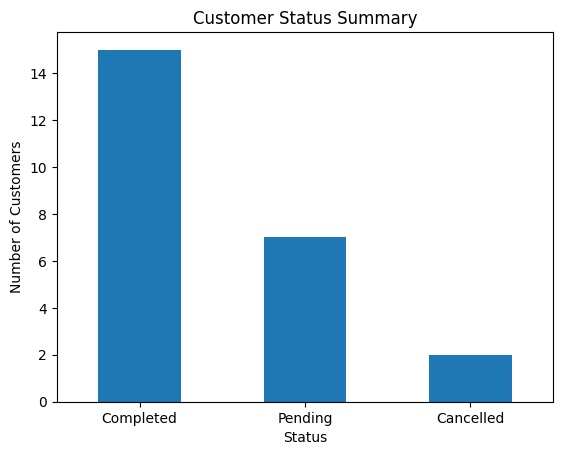

In [17]:
import matplotlib.pyplot as plt

# Status-wise report
df['Status'].value_counts().plot(kind='bar')

plt.title('Customer Status Summary')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

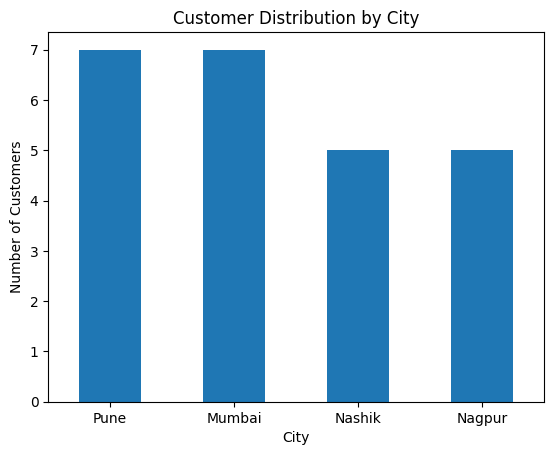

In [18]:
import matplotlib.pyplot as plt

# City-wise customer report
df['City'].value_counts().plot(kind='bar')

plt.title('Customer Distribution by City')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

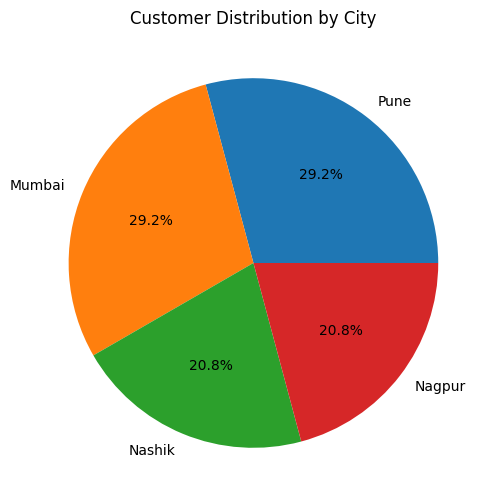

In [19]:
# City-wise customer distribution

df['City'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6)
)

plt.title('Customer Distribution by City')
plt.ylabel('')
plt.show()

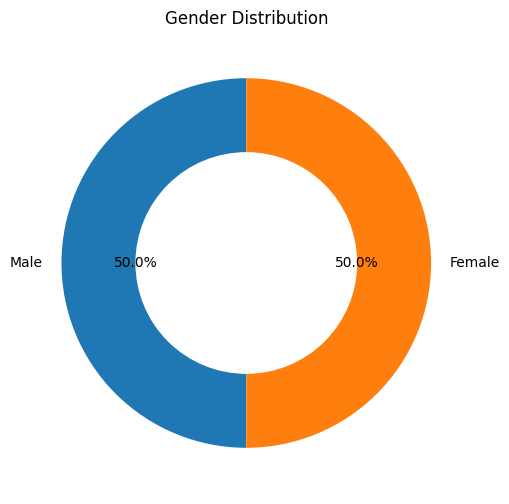

In [20]:
# Gender-wise Donut Chart

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Gender Distribution')
plt.show()

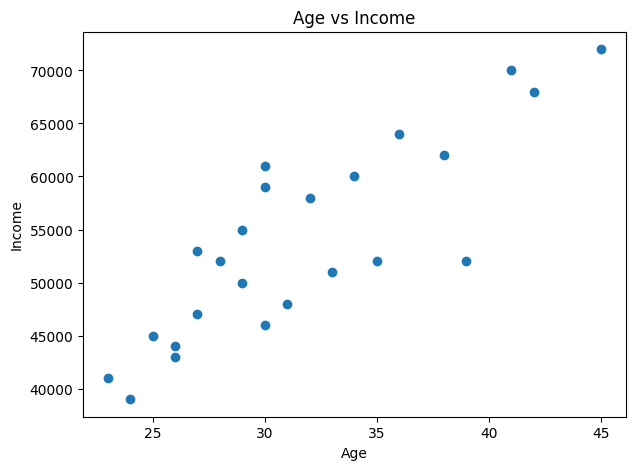

In [23]:
# Age vs Income line Plot

plt.figure(figsize=(7, 5))

plt.scatter(df['Age'], df['Income'])

plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')

plt.show()

In [24]:
# Save final cleaned dataset

df.to_csv(
    '/content/Thiranex_Task4_Final_Cleaned_Dataset.csv',
    index=False
)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [25]:
# Create Automated Excel Report

with pd.ExcelWriter('/content/Thiranex_Task4_Automated_Report.xlsx') as writer:

    # 1. Cleaned Data
    df.to_excel(writer, sheet_name='Cleaned Data', index=False)

    # 2. Overall Summary
    summary = pd.DataFrame({
        'Metric': [
            'Total Customers',
            'Average Age',
            'Average Income'
        ],
        'Value': [
            len(df),
            round(df['Age'].mean(), 2),
            round(df['Income'].mean(), 2)
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

    # 3. Status Summary
    status_summary = df['Status'].value_counts().reset_index()
    status_summary.columns = ['Status', 'Customer Count']
    status_summary.to_excel(writer, sheet_name='Status Summary', index=False)

    # 4. City Summary
    city_summary = df['City'].value_counts().reset_index()
    city_summary.columns = ['City', 'Customer Count']
    city_summary.to_excel(writer, sheet_name='City Summary', index=False)

    # 5. Gender Summary
    gender_summary = df['Gender'].value_counts().reset_index()
    gender_summary.columns = ['Gender', 'Customer Count']
    gender_summary.to_excel(writer, sheet_name='Gender Summary', index=False)

print("Automated Excel Report created successfully!")

Automated Excel Report created successfully!
